<h3>เป้าหมายที่ 4: สร้างหลักประกันว่าทุกคนมีการศึกษาที่มีคุณภาพอย่างครอบคลุมและเท่าเทียม และสนับสนุนโอกาสในการเรียนรู้ตลอดชีวิต </h3>

<h3>เป้าหมายที่ 10: ลดความไม่เสมอภาคภายในและระหว่างประเทศ</h3>

In [1]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp



In [5]:
import cv2

print("OpenCV version:", cv2.__version__)
cuda_enabled = cv2.cuda.getCudaEnabledDeviceCount() > 0

if cuda_enabled:
    print("✅ CUDA is available and enabled!")
    print("Device Name:", cv2.cuda.getDevice())
else:
    print("❌ CUDA is NOT available.")


OpenCV version: 4.11.0
❌ CUDA is NOT available.


<h2>Keypoint MP Holistic</h2>

In [6]:
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_face_mesh = mp.solutions.face_mesh

In [7]:
def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # COLOR CONVERSION BGR 2 RGB
    image.flags.writeable = False                  # Image is no longer writeable
    results = model.process(image)                 # Make prediction
    image.flags.writeable = True                   # Image is now writeable 
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR) # COLOR COVERSION RGB 2 BGR
    return image, results

In [8]:
def draw_landmarks(image, results):
    # Face landmarks
    if results.face_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.face_landmarks, 
            mp_face_mesh.FACEMESH_CONTOURS  # แก้ไขเป็น FACEMESH_CONTOURS
        )

    # Pose landmarks
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS
        )
    
    # Left hand landmarks
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )

    # Right hand landmarks
    if results.right_hand_landmarks:
        mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS
        )


In [9]:
def draw_styled_landmarks(image, results):
    mp_drawing.draw_landmarks(
            image, 
            results.face_landmarks, 
            mp_face_mesh.FACEMESH_CONTOURS ,
            mp_drawing.DrawingSpec(color=(80,110,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,256,121), thickness=1, circle_radius=1)
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.pose_landmarks, 
            mp_holistic.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(80,22,10), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(80,44,121), thickness=1, circle_radius=1)
            
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.left_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(121,22,76), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(121,44,250), thickness=1, circle_radius=1)
        )
    
    mp_drawing.draw_landmarks(
            image, 
            results.right_hand_landmarks, 
            mp_holistic.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(245,117,66), thickness=1, circle_radius=1),
            mp_drawing.DrawingSpec(color=(245,66,2330), thickness=1, circle_radius=1)
        )

In [ ]:
# เปิดกล้อง (0 = กล้องตัวแรก)
cap = cv2.VideoCapture(0)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
# วนลูปรับภาพจากกล้อง
    while cap.isOpened():
        # อ่านภาพจากกล้อง
        ret, frame = cap.read()

        image, results = mediapipe_detection(frame, holistic)
        # print(results)

        draw_styled_landmarks(frame, results)

        # แสดงภาพบนหน้าจอ
        cv2.imshow('OpenCV Feed', frame)

        # รอปุ่ม 'q' เพื่อออกจากลูป
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

# ปิดการเชื่อมต่อกล้องและหน้าต่าง
cap.release()
cv2.destroyAllWindows()


[ WARN:0@42.845] global cap_gstreamer.cpp:1777 open OpenCV | GStreamer warning: Cannot query video position: status=0, value=-1, duration=-1
Error in cpuinfo: prctl(PR_SVE_GET_VL) failed
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1750613201.144342   61679 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750613201.187124   61681 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750613201.191620   61683 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750613201.192985   61681 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1750613201.193427

In [9]:
len(results.left_hand_landmarks.landmark)

21

In [10]:
results

mediapipe.python.solution_base.SolutionOutputs

In [7]:
draw_styled_landmarks(frame, results)

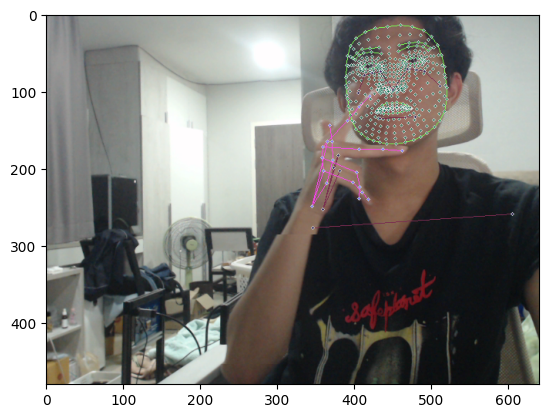

In [73]:
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

<h2>Extract Keypoint Values</h2>

In [10]:
len(results.left_hand_landmarks.landmark)

NameError: name 'results' is not defined

In [14]:
len(results.pose_landmarks.landmark)

33

In [15]:
pose = []
for res in results.pose_landmarks.landmark:
    test = np.array([res.x, res.y, res.z, res.visibility])
    pose.append(test)

In [33]:
pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(132)
face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(1404)
lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

<h3>extract_kp</h3>

In [8]:
def extract_keypoints(results):
    pose = np.array([[res.x, res.y, res.z, res.visibility] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*4)
    face = np.array([[res.x, res.y, res.z] for res in results.face_landmarks.landmark]).flatten() if results.face_landmarks else np.zeros(468*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)
    return np.concatenate([pose, face, lh, rh])

In [31]:
result_test = extract_keypoints(results)

NameError: name 'results' is not defined

In [ ]:
result_test #468*3+33*4+21*3+21*3

array([ 0.54259491,  0.40736383, -1.00223136, ...,  0.12213195,
        0.27519989, -0.09239911])

<h2>Setup Folder for Collect data</h2>

In [9]:
# Path for exported data, numpy arrays
DATA_PATH = os.path.join('MP_Data') 

# Actions that we try to detect                                            
actions = np.array(['hello', 'thank','recommended' ,'tawlai'
                    , 'noSweet', 'sweetLess', 'sweetMore', 'sweetNormal'
                    , 'cocoa', 'greentea', 'thaitea'
                    ])
                    # , 'americano', 'latte'
                    # , 'milk', 'black'
                    # , 'coffee
fix_actions = ['hello', 'thank','recommended','one' , 'nee','tangmod' ,'tawlai']
# Thirty videos worth of data
no_sequences = 100

# Videos are going to be 30 frames in length
sequence_length = 30

In [ ]:
# hello
## 0
## 1
## 2
## ...
## 29
# thanks

# I love you

In [10]:
for action in actions: 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH, action, str(sequence)))
        except:
            pass

<h2>Collect Keypoint Values for Training and Testing</h2>

In [8]:
target_actions = ['hello']

In [69]:
cap = cv2.VideoCapture(2)
cap.set(cv2.CAP_PROP_FRAME_WIDTH, 640)
cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 360)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    # Loop through actions
    for action in target_actions:
        # Loop through sequences aka videos
        for sequence in range(no_sequences):
            # Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                # Read feed
                ret, frame = cap.read()

                # Make detections
                image, results = mediapipe_detection(frame, holistic)
#                 print(results)

                # Draw landmarks
                draw_styled_landmarks(image, results)
                
                # NEW Apply wait logic
                if frame_num == 0: 
                    cv2.putText(image, 'STARTING COLLECTION', (120,200), 
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255, 0), 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                    cv2.waitKey(2000)
                else: 
                    cv2.putText(image, 'Collecting frames for {} Video Number {}'.format(action, sequence), (15,12), 
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1, cv2.LINE_AA)
                    # Show to screen
                    cv2.imshow('OpenCV Feed', image)
                
                # NEW Export keypoints
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH, action, str(sequence), str(frame_num))
                np.save(npy_path, keypoints)

                # Break gracefully
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break
                    
    cap.release()
    cv2.destroyAllWindows()

[ WARN:0@716.421] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
I0000 00:00:1743721393.050564    1144 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1743721393.061392    3908 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 24.2.8-1ubuntu1~24.04.1), renderer: D3D12 (Intel(R) Iris(R) Xe Graphics)
W0000 00:00:1743721393.114917    3901 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743721393.133391    3899 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743721393.135653    3903 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743721393.136100    3900 infer

NameError: name 'target_actions' is not defined

In [212]:
cap.release()
cv2.destroyAllWindows()

NameError: name 'cap' is not defined

<h2>6. Preprocess Data and Create Labels and Features</h2>

In [11]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

In [12]:
label_map = {label:num for num, label in enumerate(actions)}


In [13]:
label_map

{'hello': 0,
 'thank': 1,
 'recommended': 2,
 'tawlai': 3,
 'noSweet': 4,
 'sweetLess': 5,
 'sweetMore': 6,
 'sweetNormal': 7,
 'cocoa': 8,
 'greentea': 9,
 'thaitea': 10}

In [14]:
newno_sequences = 60
newsequence_length = 30

In [14]:
sequences, labels = [], []
for action in actions:
    for sequence in range(no_sequences):
        window = []
        for frame_num in range(sequence_length):
            res = np.load(os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num)))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

In [16]:
np.array(sequences).shape

(1100, 30, 1662)

In [17]:

np.array(labels).shape

(1100,)

In [18]:
X = np.array(sequences)

In [19]:
X.shape

(1100, 30, 1662)

In [20]:
y = to_categorical(labels).astype(int)

In [21]:
y

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05)

In [23]:
y_train.shape

(1045, 11)

In [24]:
y_test.shape

(55, 11)

<h2>7. Build and Train LSTM Neural Network</h2>

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input,Dropout
from tensorflow.keras.callbacks import TensorBoard,EarlyStopping

In [26]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [27]:
model = Sequential()
model.add(Input(shape=(30, 1662)))
model.add(LSTM(64, return_sequences=True, activation='relu'))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(len(actions), activation='softmax'))

I0000 00:00:1743720750.587080    1144 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 1662)))
model.add(LSTM(128, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

In [28]:
res = [.7, 0.2, 0.1]

In [29]:
actions[np.argmax(res)]

'hello'

In [36]:
learning_rate = 1e-4

In [37]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=learning_rate)

In [38]:
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

In [39]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

earlystop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

model.fit(X_train, y_train, epochs=200, validation_split=0.2,
          callbacks=[tb_callback, earlystop, reduce_lr], batch_size=8)

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - categorical_accuracy: 0.0845 - loss: nan - val_categorical_accuracy: 0.0957 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.1049 - loss: nan - val_categorical_accuracy: 0.0957 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.0832 - loss: nan - val_categorical_accuracy: 0.0957 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - categorical_accuracy: 0.0880 - loss: nan - val_categorical_accuracy: 0.0957 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.0831 - loss: nan - val_categorical_accuracy: 0.0957 - val_loss: nan - learning_rate: 1.0000e-04
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.0790 - loss: nan - val_categorical_accur

In [ ]:
model.fit(X_train, y_train, epochs=200, validation_split=0.2, callbacks=[tb_callback], batch_size=16)

2025-06-23 00:16:21.077668: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 166731840 exceeds 10% of free system memory.
2025-06-23 00:16:21.292091: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 166731840 exceeds 10% of free system memory.


Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - categorical_accuracy: 0.0940 - loss: 2.3983 - val_categorical_accuracy: 0.1148 - val_loss: 2.4181
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - categorical_accuracy: 0.0782 - loss: 2.3989 - val_categorical_accuracy: 0.0622 - val_loss: 2.4065
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.0770 - loss: 2.3999 - val_categorical_accuracy: 0.0957 - val_loss: 2.4183
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - categorical_accuracy: 0.0935 - loss: 2.3986 - val_categorical_accuracy: 0.0861 - val_loss: 2.4091
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - categorical_accuracy: 0.1053 - loss: 2.3988 - val_categorical_accuracy: 0.0813 - val_loss: 2.4055
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - categorical_accuracy: 0.1096 - loss: 2.3966 - val_categorical_accuracy: 0.0813 - val_loss: 2.4057
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - categorical_accurac

KeyboardInterrupt: 

In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │       236,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 876,131 (3.34 MB)

 Trainable params: 292,043 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 584,088 (2.23 MB)

<h2>8. Make Predictions</h2>

In [51]:

res = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step


In [54]:
actions[np.argmax(res[12])]

'hello'

In [53]:

actions[np.argmax(y_test[12])]

'recommended'

In [271]:
for i in range(54):  # หรือ range(0, 54)
    predicted_label = actions[np.argmax(res[i])]
    print(f"res[{i}] => {predicted_label}")


res[0] => tawlai
res[1] => cocoa
res[2] => recommended
res[3] => latte
res[4] => less
res[5] => nee
res[6] => green
res[7] => one
res[8] => zero
res[9] => latte
res[10] => tangmod
res[11] => no
res[12] => nee
res[13] => normal
res[14] => one
res[15] => thai
res[16] => nee
res[17] => one
res[18] => tangmod
res[19] => recommended
res[20] => recommended
res[21] => tawlai
res[22] => one
res[23] => tangmod
res[24] => normal
res[25] => one
res[26] => americano
res[27] => latte
res[28] => sweet
res[29] => one
res[30] => thai
res[31] => thank
res[32] => tangmod
res[33] => less
res[34] => zero
res[35] => nee
res[36] => thank
res[37] => green
res[38] => americano
res[39] => nee
res[40] => tawlai
res[41] => thai
res[42] => normal
res[43] => cocoa
res[44] => hello
res[45] => cocoa
res[46] => latte
res[47] => latte
res[48] => latte
res[49] => normal
res[50] => latte
res[51] => latte
res[52] => americano
res[53] => hello


In [55]:
for i in range(54):
    predicted = actions[np.argmax(res[i])]
    actual = actions[np.argmax(y_test[i])]
    print(f"res[{i}] => Predict: {predicted} | Actual: {actual}")


res[0] => Predict: hello | Actual: noSweet
res[1] => Predict: hello | Actual: sweetMore
res[2] => Predict: hello | Actual: thaitea
res[3] => Predict: hello | Actual: sweetLess
res[4] => Predict: hello | Actual: hello
res[5] => Predict: hello | Actual: greentea
res[6] => Predict: hello | Actual: recommended
res[7] => Predict: hello | Actual: sweetNormal
res[8] => Predict: hello | Actual: tawlai
res[9] => Predict: hello | Actual: hello
res[10] => Predict: hello | Actual: noSweet
res[11] => Predict: hello | Actual: thaitea
res[12] => Predict: hello | Actual: recommended
res[13] => Predict: hello | Actual: tawlai
res[14] => Predict: hello | Actual: hello
res[15] => Predict: hello | Actual: noSweet
res[16] => Predict: hello | Actual: recommended
res[17] => Predict: hello | Actual: thaitea
res[18] => Predict: hello | Actual: thank
res[19] => Predict: hello | Actual: recommended
res[20] => Predict: hello | Actual: hello
res[21] => Predict: hello | Actual: sweetMore
res[22] => Predict: hello |

In [554]:

actions[y_test[0]]

array(['hello', 'hello', 'hello', 'hello', 'hello', 'hello', 'thank',
       'hello', 'hello', 'hello', 'hello', 'hello', 'hello', 'hello',
       'hello', 'hello'], dtype='<U11')

In [273]:
model.save('deslr_18c.h5')

In [275]:
del model

In [31]:
model.load_weights('deslr_18c.h5')

<h2>Evaluation use Confusion Matrix and Accuracy</h2>

In [32]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [38]:
yhat = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [39]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [40]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[52,  0],
        [ 0,  2]],

       [[53,  0],
        [ 0,  1]],

       [[50,  0],
        [ 0,  4]],

       [[52,  0],
        [ 0,  2]],

       [[51,  0],
        [ 0,  3]],

       [[52,  0],
        [ 0,  2]],

       [[49,  0],
        [ 0,  5]],

       [[52,  0],
        [ 0,  2]],

       [[51,  0],
        [ 0,  3]],

       [[52,  0],
        [ 0,  2]],

       [[49,  0],
        [ 0,  5]],

       [[48,  0],
        [ 0,  6]],

       [[49,  0],
        [ 0,  5]],

       [[52,  0],
        [ 0,  2]],

       [[52,  0],
        [ 0,  2]],

       [[52,  0],
        [ 0,  2]],

       [[52,  0],
        [ 0,  2]],

       [[50,  0],
        [ 0,  4]]])

In [41]:
accuracy_score(ytrue, yhat)

1.0

In [42]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report

print(multilabel_confusion_matrix(ytrue, yhat))
print(classification_report(ytrue, yhat))


[[[52  0]
  [ 0  2]]

 [[53  0]
  [ 0  1]]

 [[50  0]
  [ 0  4]]

 [[52  0]
  [ 0  2]]

 [[51  0]
  [ 0  3]]

 [[52  0]
  [ 0  2]]

 [[49  0]
  [ 0  5]]

 [[52  0]
  [ 0  2]]

 [[51  0]
  [ 0  3]]

 [[52  0]
  [ 0  2]]

 [[49  0]
  [ 0  5]]

 [[48  0]
  [ 0  6]]

 [[49  0]
  [ 0  5]]

 [[52  0]
  [ 0  2]]

 [[52  0]
  [ 0  2]]

 [[52  0]
  [ 0  2]]

 [[52  0]
  [ 0  2]]

 [[50  0]
  [ 0  4]]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         2
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         2
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
         

<h2>Test</h2>

In [58]:
from scipy import stats

In [66]:
colors = [
    (255, 99, 71),     # Tomato
    (135, 206, 235),   # Sky Blue
    (124, 252, 0),     # Lawn Green
    (255, 215, 0),     # Gold
    (186, 85, 211),    # Medium Orchid
    (60, 179, 113),    # Medium Sea Green
    (255, 140, 0),     # Dark Orange
    (30, 144, 255),    # Dodger Blue
    (220, 20, 60),     # Crimson
    (218, 165, 32),    # Goldenrod
    (255, 105, 180),   # Hot Pink
    (0, 191, 255),     # Deep Sky Blue
    (154, 205, 50),    # Yellow Green
    (123, 104, 238),   # Medium Slate Blue
    (255, 69, 0),      # Orange Red
    (0, 255, 255),     # Cyan
    (0, 250, 154),     # Medium Spring Green
    (255, 182, 193)    # Light Pink
]


In [67]:

def prob_viz(res, actions, input_frame, colors):
    output_frame = input_frame.copy()
    for num, prob in enumerate(res):
        cv2.rectangle(output_frame, (0,60+num*40), (int(prob*100), 90+num*40), colors[num], -1)
        cv2.putText(output_frame, actions[num], (0, 85+num*40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)
        
    return output_frame

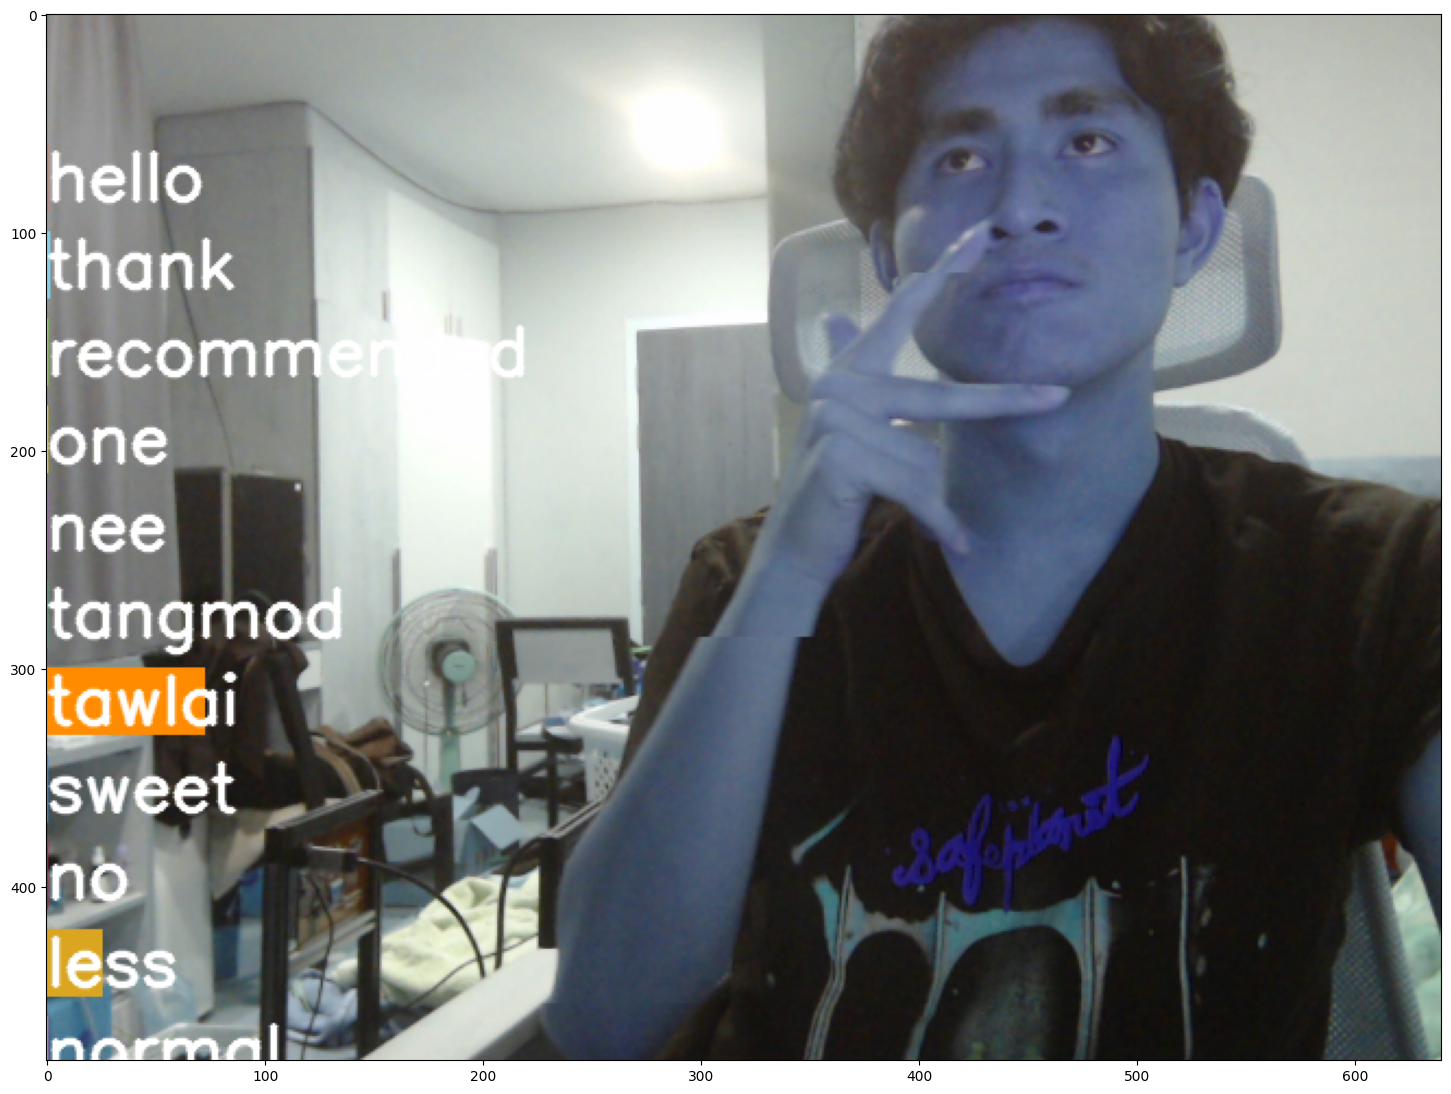

In [74]:
plt.figure(figsize=(18,18))
plt.imshow(prob_viz(res, actions, image, colors))

In [75]:
sequence.reverse()

In [76]:
len(sequence)

30

In [77]:
sequence[-30:]

[array([ 0.67115533,  0.25428611, -0.64625823, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67132938,  0.2548247 , -0.64241034, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67185104,  0.25511658, -0.64389986, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67195046,  0.25627354, -0.66426057, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67232025,  0.25742656, -0.64912814, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67340171,  0.26074198, -0.61059135, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67546481,  0.26543641, -0.72078496, ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67739713,  0.2676895 , -0.8825196 , ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.67660177,  0.25010592, -0.8911761 , ...,  0.        ,
         0.        ,  0.        ]),
 array([ 0.6644733 ,  0.21960773, -0.87937868, ...,  0.        ,
         0.        ,  0.  

In [84]:
sequence = []
sentence = []
threshold = 0.9

cap = cv2.VideoCapture(0)
# Set mediapipe model 
with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():

        # Read feed
        ret, frame = cap.read()

        # Make detections
        image, results = mediapipe_detection(frame, holistic)
        print(results)
        
        # Draw landmarks
        draw_styled_landmarks(image, results)
        
        # 2. Prediction logic
        keypoints = extract_keypoints(results)
#         sequence.insert(0,keypoints)
#         sequence = sequence[:30]
        sequence.append(keypoints)
        sequence = sequence[-30:]
        
        if len(sequence) == 30:
            res = model.predict(np.expand_dims(sequence, axis=0))[0]
            print(actions[np.argmax(res)])
            
            
        #3. Viz logic
            if res[np.argmax(res)] > threshold:
                predictions_queue.append(actions[np.argmax(res)])
                
                if len(predictions_queue) > 3:
                    predictions_queue = predictions_queue[-3:]

                    if predictions_queue.count(predictions_queue[0]) == 3:
                        if len(sentence) == 0 or predictions_queue[0] != sentence[-1]:
                            sentence.append(predictions_queue[0])

            if len(sentence) > 5: 
                sentence = sentence[-5:]

            # Viz probabilities
            image = prob_viz(res, actions, image, colors)
            
        cv2.rectangle(image, (0,0), (640, 40), (245, 117, 16), -1)
        cv2.putText(image, ' '.join(sentence), (3,30), 
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        
        # Show to screen
        cv2.imshow('OpenCV Feed', image)

        # Break gracefully
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()

[ WARN:0@3650.464] global cap_gstreamer.cpp:1173 isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created
I0000 00:00:1743724471.791327    1144 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1743724471.807866   59101 gl_context.cc:369] GL version: 3.0 (OpenGL ES 3.0 Mesa 24.2.8-1ubuntu1~24.04.1), renderer: D3D12 (Intel(R) Iris(R) Xe Graphics)
W0000 00:00:1743724471.898599   59093 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743724471.935430   59097 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743724471.938850   59093 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1743724471.938908   59096 infe

<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.solution_base.SolutionOutputs'>
<class 'mediapipe.python.soluti

In [65]:
cap.release()
cv2.destroyAllWindows()